In [1]:
file_path = r"C:\Users\jreyesva\OneDrive - Intel Corporation\Documents\Proyectos Intel\Kaseville (KSV)\Measurements\03_CLKOUT_SRC_0_Jitter.csv"
import numpy as np
cross_times = np.loadtxt(file_path, delimiter=",")
print(cross_times.shape)

(110000,)


In [17]:
cross_times = cross_times[2:]

In [3]:
import matplotlib.pyplot as plt

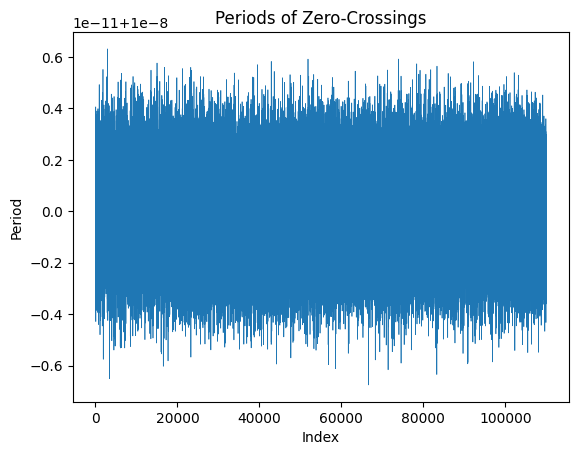

In [18]:
periods = np.diff(cross_times)
plt.plot(periods, linewidth=0.5)
plt.xlabel("Index")
plt.ylabel("Period")
plt.title("Periods of Zero-Crossings")
plt.show()

Fitted frequency (Hz): 99999988.05024926


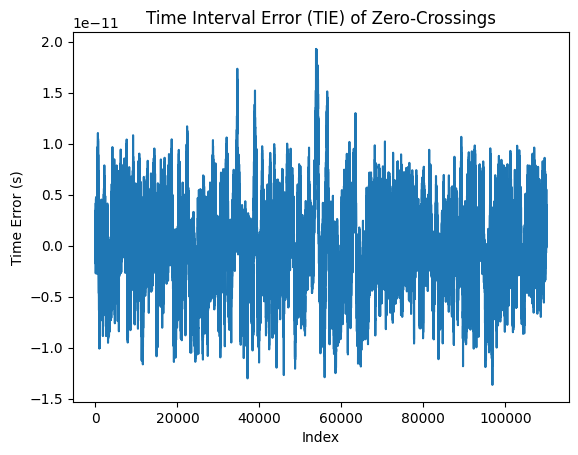

In [19]:
edge_index = np.arange(cross_times.size, dtype=float)
fitted_period_s, fitted_intercept_s = np.polyfit(edge_index, cross_times, 1)
fitted_frequency_hz = 1.0 / fitted_period_s
ideal_crossing_times_fitted_s = fitted_intercept_s + fitted_period_s * edge_index
tie_fitted_s = cross_times - ideal_crossing_times_fitted_s
print(f"Fitted frequency (Hz): {fitted_frequency_hz}")
plt.plot(tie_fitted_s)
plt.xlabel("Index")
plt.ylabel("Time Error (s)")
plt.title("Time Interval Error (TIE) of Zero-Crossings")
plt.show()

Frequency (Hz): 99999987.88191307


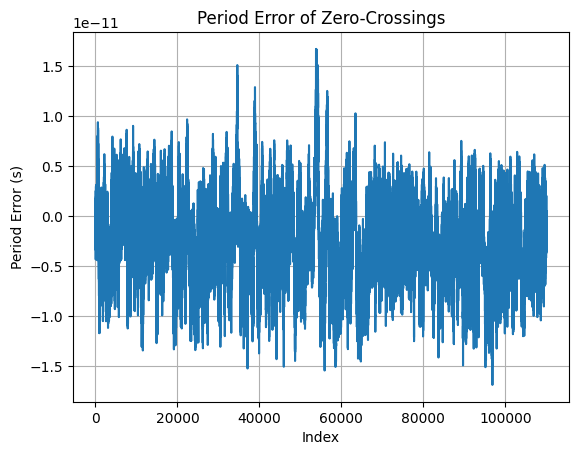

In [20]:
tie_2 = np.cumsum(periods - np.mean(periods))
print(f"Frequency (Hz): {1.0 / np.mean(periods)}")
plt.plot(tie_2)
plt.xlabel("Index")
plt.ylabel("Period Error (s)")
plt.title("Period Error of Zero-Crossings")
plt.grid(True)
plt.show()